# Imports

In [1]:
# Data Parsing:
import pandas as pd
from pathlib import Path
import warnings
import requests
import sys
import numpy as np

# Visualizations:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Module path:
PROJECT_ROOT = Path().resolve()
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Custom modules:
import experiment
from experiment import load_jsonl, run_experiment
from analysis_tools import analyze_run, patch_scores_csv_for_analysis
from gpt import ScratchGPTBackend, fake_post, configure_scratch_backend

### Settings:

In [2]:
# Cleaner visualizations:
sns.set_theme()

# For consistency:
seed = 28980
np.random.seed(seed)

# Omit warnings:
warnings.filterwarnings('ignore')

## Scratch GPT integration

In [3]:
# Local backend to match Ollama models:
CUSTOM_GPT_NAME = 'scratch-gpt'
CUSTOM_GPT_CONFIG = {'weights_path': 'model_weights.pt',
                     'tokenizer_dir': './hftokenizer',
                     'd_model': 1024,
                     'n_heads': 16,
                     'layers': 32,
                     'vocab_size': 10000,
                     'max_seq_len': 512,
                     }

scratch_backend = ScratchGPTBackend(CUSTOM_GPT_CONFIG)
configure_scratch_backend(scratch_backend)

requests.post = fake_post
experiment.requests.post = fake_post

# Full Run:

### Load Task Dataset:

In [4]:
ifeval = load_jsonl('data_processed/tasks_ifeval.jsonl')
ifeval_fc = load_jsonl('data_processed/tasks_ifeval_fc.jsonl')
run_id_custom = 'RUN_IFEVAL_All'
run_id_fc_custom = 'RUN_IFEVALFC_All'

print('IFEval:', len(ifeval))
print('IFEval-FC:', len(ifeval_fc))

IFEval: 541
IFEval-FC: 750


### Launch IfEval-FC Run:

In [ ]:
%%time

rng = random.Random(seed)
ifeval_fc_shuffle = ifeval_fc.copy()
rng.shuffle(ifeval_fc_shuffle)
ifeval_fc_tasks = ifeval_fc_shuffle

run_experiment(
    run_id=run_id_fc_custom,
    models=['qwen3:8b', 'llama3.2:3b', 'gemma3:12b', 'gpt-oss:20b', CUSTOM_GPT_NAME],
    tasks=ifeval_fc_tasks,
    repeats=10,
    temperature=0.7,
    num_predict=128,
    progress_every=720,
    endpoint='http://localhost:11434/api/generate',
    )

### Launch IfEval Run:

In [ ]:
%%time

rng = random.Random(seed)
ifeval_shuffle = ifeval.copy()
rng.shuffle(ifeval_shuffle)
ifeval_tasks = ifeval_shuffle

run_experiment(
    run_id=run_id_custom,
    models=['qwen3:8b', 'llama3.2:3b', 'gemma3:12b', 'gpt-oss:20b', CUSTOM_GPT_NAME],
    tasks=ifeval_tasks,
    repeats=10,
    temperature=0.7,
    num_predict=256,
    progress_every=720,
    endpoint='http://localhost:11434/api/generate',
    )

# Evaluate Results:

In [5]:
# Patch the two new custom runs before analysis
patch_scores_csv_for_analysis(run_id_custom, "custom-gpt")
patch_scores_csv_for_analysis(run_id_fc_custom, "custom-gpt")

# Analyze the existing 4-model runs plus the new custom-GPT-only runs
res_ifeval_base = analyze_run("RUN_IFEVAL_All")
res_ifeval_fc_base = analyze_run("RUN_IFEVALFC_All")

res_ifeval_custom = analyze_run(run_id_custom)
res_ifeval_fc_custom = analyze_run(run_id_fc_custom)

# Combine raw scores first
ifeval_scores = pd.concat(
    [res_ifeval_base["scores"], res_ifeval_custom["scores"]],
    ignore_index=True,
)

ifeval_fc_scores = pd.concat(
    [res_ifeval_fc_base["scores"], res_ifeval_fc_custom["scores"]],
    ignore_index=True,
)

# Add dataset-evaluation labels
ifeval_scores["dataset_eval"] = "ifeval"
ifeval_fc_scores["dataset_eval"] = "ifeval-fc"

combined_scores = pd.concat(
    [ifeval_scores, ifeval_fc_scores],
    ignore_index=True,
)

# Recompute model/topology summary from raw scores
combined_model_topo = (
    combined_scores
    .groupby(["dataset_eval", "model", "topology_id"], as_index=False)
    .agg(
        n=("overall_pass", "size"),
        pass_rate=("overall_pass", "mean"),
        pass_std=("overall_pass", "std"),
        json_rate=("valid_json", "mean"),
        schema_rate=("schema_ok", lambda x: (x == 1).mean() if (x != -1).any() else float("nan")),
        format_rate=("format_ok", lambda x: (x == 1).mean() if (x != -1).any() else float("nan")),
    )
    .sort_values(["dataset_eval", "model", "topology_id"]))

Patched runs\RUN_IFEVAL_All\scores.csv with columns: ['task_id', 'dataset', 'task_type', 'model', 'topology_id', 'repeat_id', 'temperature', 'top_p', 'num_predict', 'valid_json', 'schema_ok', 'format_ok', 'format_name', 'banned_ok', 'bullets_ok', 'overall_pass']
Patched runs\RUN_IFEVALFC_All\scores.csv with columns: ['task_id', 'dataset', 'task_type', 'model', 'topology_id', 'repeat_id', 'temperature', 'top_p', 'num_predict', 'valid_json', 'schema_ok', 'format_ok', 'format_name', 'banned_ok', 'bullets_ok', 'overall_pass']


In [6]:
# Model-level summary
model_summary = (
    combined_scores
    .groupby(["dataset_eval", "model"], as_index=False)
    .agg(
        total_n=("overall_pass", "size"),
        mean_pass_rate=("overall_pass", "mean"),
        mean_json_rate=("valid_json", "mean"),
        mean_schema_rate=("schema_ok", lambda x: (x == 1).mean() if (x != -1).any() else float("nan")),
        mean_format_rate=("format_ok", lambda x: (x == 1).mean() if (x != -1).any() else float("nan")),
    )
    .sort_values(["dataset_eval", "mean_pass_rate"], ascending=[True, False])
)

# Topology-level summary
topology_summary = (
    combined_scores
    .groupby(["dataset_eval", "topology_id"], as_index=False)
    .agg(
        total_n=("overall_pass", "size"),
        mean_pass_rate=("overall_pass", "mean"),
        mean_json_rate=("valid_json", "mean"),
        mean_schema_rate=("schema_ok", lambda x: (x == 1).mean() if (x != -1).any() else float("nan")),
        mean_format_rate=("format_ok", lambda x: (x == 1).mean() if (x != -1).any() else float("nan")),
    )
    .sort_values(["dataset_eval", "mean_pass_rate"], ascending=[True, False])
)

for ds in ["ifeval", "ifeval-fc"]:
    
    pivot_pass = (
        combined_model_topo[combined_model_topo["dataset_eval"] == ds]
        .pivot_table(
            index="topology_id",
            columns="model",
            values="pass_rate",
            aggfunc="mean"
        )
        .sort_index()
    )

pivot_schema_fc = (
    combined_model_topo[combined_model_topo["dataset_eval"] == "ifeval-fc"]
    .pivot_table(
        index="topology_id",
        columns="model",
        values="schema_rate",
        aggfunc="mean"
    )
    .sort_index()
)

pivot_format_fc = (
    combined_model_topo[combined_model_topo["dataset_eval"] == "ifeval-fc"]
    .pivot_table(
        index="topology_id",
        columns="model",
        values="format_rate",
        aggfunc="mean"
    )
    .sort_index()
)

scores_all = combined_scores.copy()

scores_all["run_name"] = scores_all["dataset_eval"].map({
    "ifeval": "IFEval",
    "ifeval-fc": "IFEval-FC"
})

In [7]:
combined_model_topo.to_csv('runs/combined_model_topology_ifeval_and_fc.csv', index=False)
model_summary.to_csv('runs/combined_model_summary_ifeval_and_fc.csv', index=False)
topology_summary.to_csv('runs/combined_topology_summary_ifeval_and_fc.csv', index=False)
scores_all.to_csv('runs/combined_scores_ifeval_and_fc.csv', index=False)

## Visualizations:

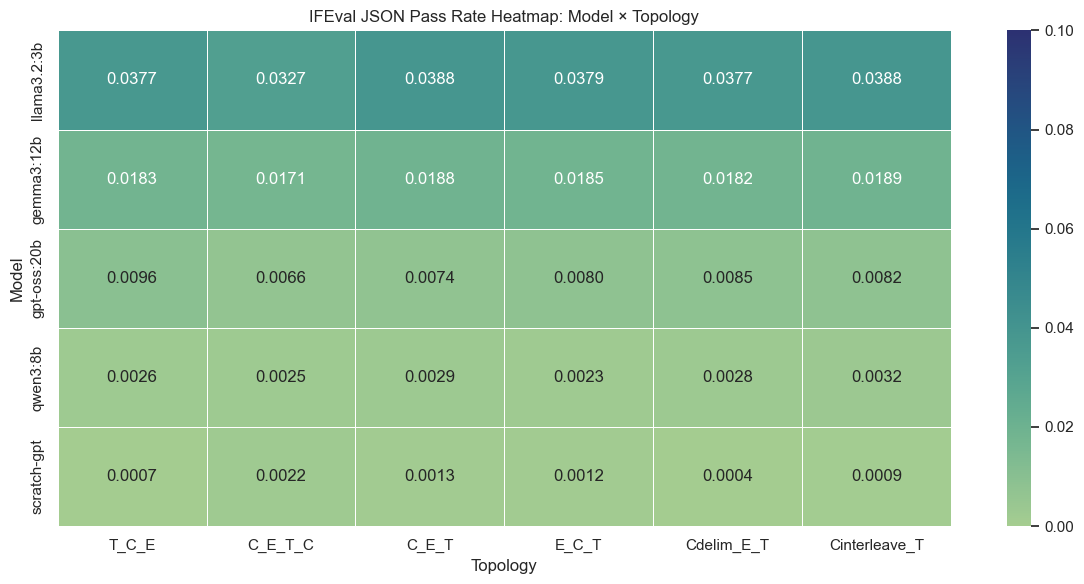

In [8]:
topo_df = pd.read_csv('./runs/combined_model_topology_ifeval_and_fc.csv')
ifeval_df = topo_df[topo_df['dataset_eval'] == 'ifeval'].copy()

pivot = ifeval_df.pivot(index='model', columns='topology_id', values='json_rate')

# Order rows/columns by average success so the structure is easier to read
row_order = pivot.mean(axis=1).sort_values(ascending=False).index
topology_order = ['T_C_E', 'C_E_T_C', 'C_E_T', 'E_C_T', 'Cdelim_E_T', 'Cinterleave_T']
pivot = pivot.loc[row_order, topology_order]

plt.figure(figsize=(12, 6))
ax = sns.heatmap(pivot,
                 annot=True,
                 fmt='.4f',
                 cmap='crest',
                 linewidths=0.5,
                 vmin=0,
                 vmax=0.1,
                 )

ax.set_title('IFEval JSON Pass Rate Heatmap: Model × Topology')
ax.set_xlabel('Topology')
ax.set_ylabel('Model')

plt.tight_layout()
output_path = Path("./runs/ifeval_pass_rate_heatmap.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

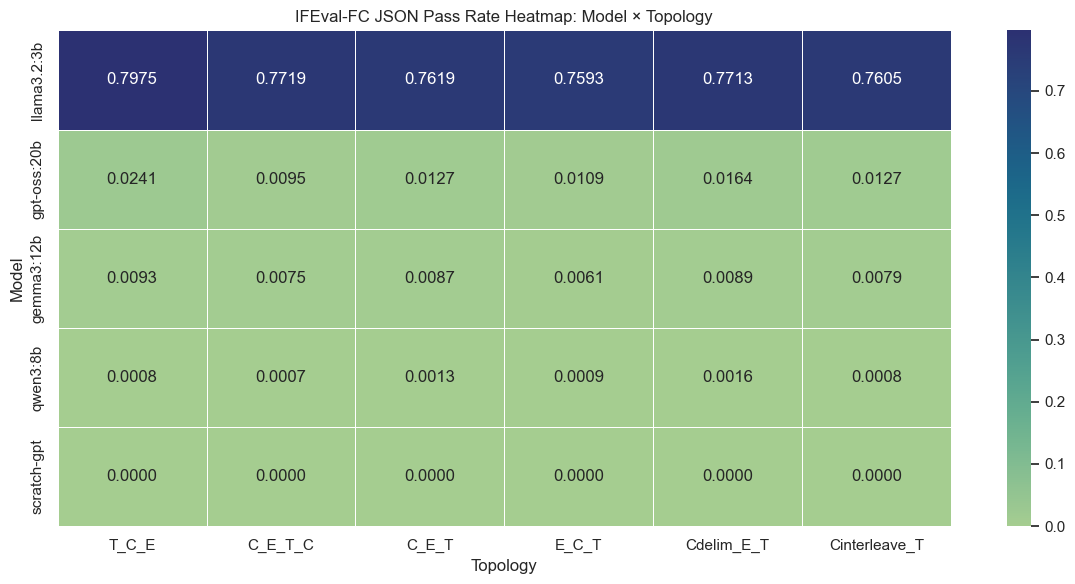

In [10]:
topo_df = pd.read_csv('./runs/combined_model_topology_ifeval_and_fc.csv')
ifevalfc_df = topo_df[topo_df['dataset_eval'] == 'ifeval-fc'].copy()

pivot = ifevalfc_df.pivot(index='model', columns='topology_id', values='json_rate')

# Order rows/columns by average success so the structure is easier to read
row_order = pivot.mean(axis=1).sort_values(ascending=False).index
topology_order = ['T_C_E', 'C_E_T_C', 'C_E_T', 'E_C_T', 'Cdelim_E_T', 'Cinterleave_T']
pivot = pivot.loc[row_order, topology_order]

plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    pivot,
    annot=True,
    fmt='.4f',
    cmap='crest',
    linewidths=0.5,
)

ax.set_title('IFEval-FC JSON Pass Rate Heatmap: Model × Topology')
ax.set_xlabel('Topology')
ax.set_ylabel('Model')

plt.tight_layout()
output_path = Path("./runs/ifeval_fc_pass_rate_heatmap.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()